# spatial-smooth: a tutorial

> ## ⚠️ This package is for looking, not for measuring
>
> `spatial-smooth` makes spatial regions **easier to see**. What it produces is a picture.
>
> Smoothing works by making each cell look more like its neighbours. That is exactly what you
> want when you are trying to spot where a gene programme is switched on — and exactly what you
> must not feed into a statistical test. Once cells have been made to resemble their neighbours
> they are no longer independent measurements, so **differential expression, cluster
> comparisons, correlations and p-values computed on smoothed values are badly over-confident**.
> They will report strong, convincing structure in data that contains none.
>
> Every call writes the unsmoothed score next to the smoothed one, as
> `adata.obs["<name>_raw"]`. **Look at the smoothed one. Do your statistics on the raw one.**

A per-cell signature score is noisy — each cell is measured independently, so dropout and
sampling variance dominate, and a real anatomical region can be genuinely hard to pick out of
the speckle. **Smoothing** lets neighbouring cells borrow statistical strength. You choose *which*
neighbours count: cells nearby in **space**, cells alike in **cell state**, or both.

This tutorial uses **`blend`** — the mode that combines the two symmetrically, so space and cell
state contribute on equal footing. It is the one to reach for by default. The other modes
(spatial-only, cell-state-only, sequential composition), the parameters, and the maths behind them
live in the **[Concepts](https://settylab.github.io/spatial-smooth/concepts.html)** documentation;
the notebook stays a clean happy-path.

The data is a public 10x Genomics Xenium mouse-brain section (CC-BY), downloaded on first run
(~4.5 MB). Nothing here needs a cluster.

## Setup

```bash
pip install "spatial-smooth[all]"
```

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import scanpy as sc

import spatial_smooth as ss

## 1. The data

### Using your own data instead

**`spatial-smooth` needs exactly two things** from an `AnnData`, and nothing else:

1. `adata.X` (or a layer you name via `layer=`) holding **log-normalised** expression, and
2. `adata.obsm["spatial"]` holding the cells' physical coordinates, as an `(n_obs, 2)` array.

So if you already have a prepared object, skip the download entirely — this is the whole of
section 1 for you:

```python
import anndata as ad
adata = ad.read_h5ad("my_section.h5ad")
assert "spatial" in adata.obsm          # (n_obs, 2) coordinates
# adata.X must be log-normalised; if it holds raw counts:
#   adata.layers["counts"] = adata.X.copy()
#   sc.pp.normalize_total(adata); sc.pp.log1p(adata)
```

Then jump to section 2. The `blend` mode also smooths over cell state, so it needs
`obsm["DM_EigenVectors"]` — a diffusion map of the expression manifold. You do not have to build it
yourself: the first `blend` call computes it for you with Palantir if it is absent (`auto_embed=True`,
the default).

### The example dataset

The rest of this notebook uses a public 10x Xenium mouse-brain coronal subset: ~36,000 cells, a
248-gene panel, one cell per row with physical centroids. We fetch the two small loose outputs
(cached, so re-running is free), assemble an `AnnData`, and put the centroids in
`obsm["spatial"]`.

In [2]:
import pathlib, urllib.request

# 10x's CDN (CloudFront) rejects the default ``Python-urllib`` User-Agent with HTTP 403,
# so present a browser-like one for the download.
_opener = urllib.request.build_opener()
_opener.addheaders = [("User-Agent", "Mozilla/5.0")]
urllib.request.install_opener(_opener)

BASE = ("https://cf.10xgenomics.com/samples/xenium/1.0.2/"
        "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP")
NAME = "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP"
DATA = pathlib.Path("data/xenium_mousebrain")
DATA.mkdir(parents=True, exist_ok=True)

# Point this at your own .h5ad to run the whole notebook on your data instead.
PREPARED = pathlib.Path("data/prepared.h5ad")

for fname in (f"{NAME}_cell_feature_matrix.h5", f"{NAME}_cells.csv.gz"):
    dest = DATA / fname
    if PREPARED.exists():
        break
    if not dest.exists():
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(f"{BASE}/{fname}", dest)
    print(f"  {fname}  ({dest.stat().st_size / 1e6:.1f} MB)")

  Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_cell_feature_matrix.h5  (2.9 MB)
  Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_cells.csv.gz  (1.7 MB)


In [3]:
import anndata as ad

if PREPARED.exists():
    # --- alternative path: load an object you prepared earlier -------------------
    adata = ad.read_h5ad(PREPARED)
    print(f"loaded {PREPARED}")
else:
    # --- example path: assemble the public Xenium section ------------------------
    adata = sc.read_10x_h5(DATA / f"{NAME}_cell_feature_matrix.h5")
    adata.var_names_make_unique()

    cells = pd.read_csv(DATA / f"{NAME}_cells.csv.gz").set_index("cell_id")
    cells.index = cells.index.astype(str)
    adata.obs_names = adata.obs_names.astype(str)
    adata.obs = adata.obs.join(cells, how="left")
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()

    sc.pp.filter_cells(adata, min_counts=10)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

# The only two preconditions, checked explicitly.
assert "spatial" in adata.obsm, "spatial-smooth needs obsm['spatial']"
assert adata.X.max() < 100, "adata.X should be log-normalised, not raw counts"

print(f"{adata.n_obs:,} cells x {adata.n_vars} genes")

36,419 cells x 248 genes


### Two things to smooth

We use two examples, and pick both by **detection rate** — the fraction of cells with any counts —
because sparsity is exactly what makes smoothing worth doing.

* A **hippocampal signature** — three well-detected dentate-gyrus / CA markers. A clean signal to
  show what the featured `blend` mode produces.
* A single **sparse gene** to *rescue*: `Chat` (choline acetyltransferase, marking cholinergic
  neurons). It is detected in only a few percent of cells — a raw speckle you could not annotate —
  yet those few positive cells cluster in a discrete nucleus. That gap between "almost invisible
  raw" and "a domain you can point at once smoothed" is the whole point of the package.

In [4]:
SIGNATURE = ["Neurod6", "Prox1", "Wfs1"]   # hippocampal markers present in this panel
SPARSE_GENE = "Chat"                        # cholinergic neurons: sparse, but spatially clustered

for g in SIGNATURE + [SPARSE_GENE]:
    assert g in adata.var_names, f"{g} is not in this panel"

def detection_rate(gene):
    """Fraction of cells with any signal (log1p(0)=0, so X>0 reads it pre- or post-log)."""
    col = adata[:, gene].X
    col = col.toarray() if hasattr(col, "toarray") else np.asarray(col)
    return float((col > 0).mean())

print("signature markers:")
for g in SIGNATURE:
    print(f"  {g:9s} detected in {detection_rate(g):5.1%} of cells")
print(f"\nsparse gene to rescue:")
print(f"  {SPARSE_GENE:9s} detected in {detection_rate(SPARSE_GENE):5.1%} of cells "
      f"-- a genuine speckle")

signature markers:
  Neurod6   detected in 48.6% of cells
  Prox1     detected in 35.6% of cells
  Wfs1      detected in 34.9% of cells

sparse gene to rescue:
  Chat      detected in  3.4% of cells -- a genuine speckle


## 2. Smooth a signature — one call

`ss.smooth(..., steps="blend")` is the whole thing. It smooths the raw expression **independently**
over space and over cell state, then returns a symmetric, range-calibrated mean of the two views —
so the result carries tissue architecture *and* cell-state structure without collapsing onto
either, and its numbers sit on the raw score's scale (they share a colour bar).

This first call also builds the diffusion map it needs (Palantir, a couple of minutes — the one
expensive step in the notebook). `ss.pl.signature` then plots the raw score beside the smoothed
one.

[2026-07-21 16:17:38,316] [INFO    ] Smoothing all 36,419 cells


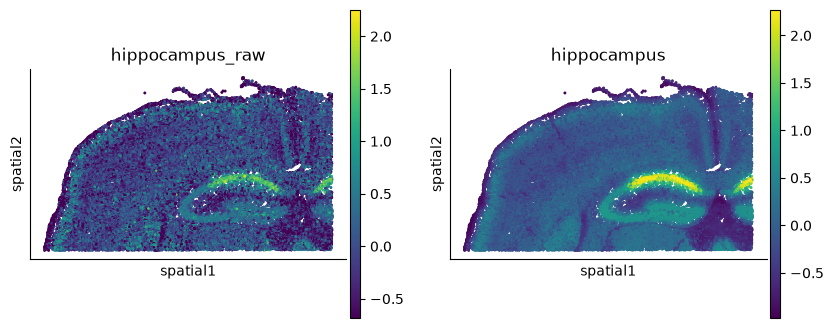

In [5]:
ss.smooth(adata, SIGNATURE, "hippocampus", steps="blend")

ss.pl.signature(adata, "hippocampus")

The raw panel is a speckle of individual cells; the blended panel resolves the dentate-gyrus
C-shape, the CA fields and the cortical layers. Two columns appeared in `obs` — the smoothed score
and its `_raw` twin — and a record of what was run in `uns`.

In [6]:
print(adata.obs[["hippocampus_raw", "hippocampus"]].describe().loc[["mean", "std", "min", "max"]].T)
print()

# Provenance: a blend records both branches and the calibration it applied.
blend = ss.provenance(adata, "hippocampus")["steps"][0]
print("genes     :", ss.provenance(adata, "hippocampus")["genes"])
print("left  view:", [s["kind"] for s in blend["left"]], "(space)")
print("right view:", [s["kind"] for s in blend["right"]], "(cell state)")
print("calibrate :", blend["calibrate"])

                         mean       std       min       max
hippocampus_raw  1.675915e-09  0.487158 -0.683196  2.249672
hippocampus      0.000000e+00  0.487158 -0.975232  2.267846

genes     : ['Neurod6', 'Prox1', 'Wfs1']
left  view: ['knn_gaussian'] (space)
right view: ['kompot_gp'] (cell state)
calibrate : std


Everything after `name` in `ss.pl.signature` is forwarded straight to the plotting backend
(scanpy or squidpy), so restyling is just kwargs — pick a colormap, a colour limit, a title.

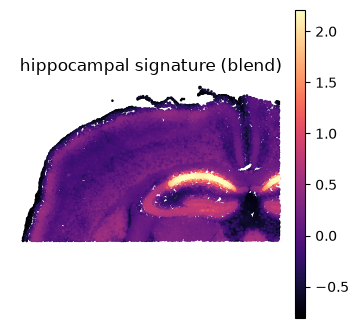

In [7]:
ss.pl.signature(
    adata, "hippocampus", raw=False,
    backend="scanpy", cmap="magma", vmax="p99.5", frameon=False,
    title="hippocampal signature (blend)",
)

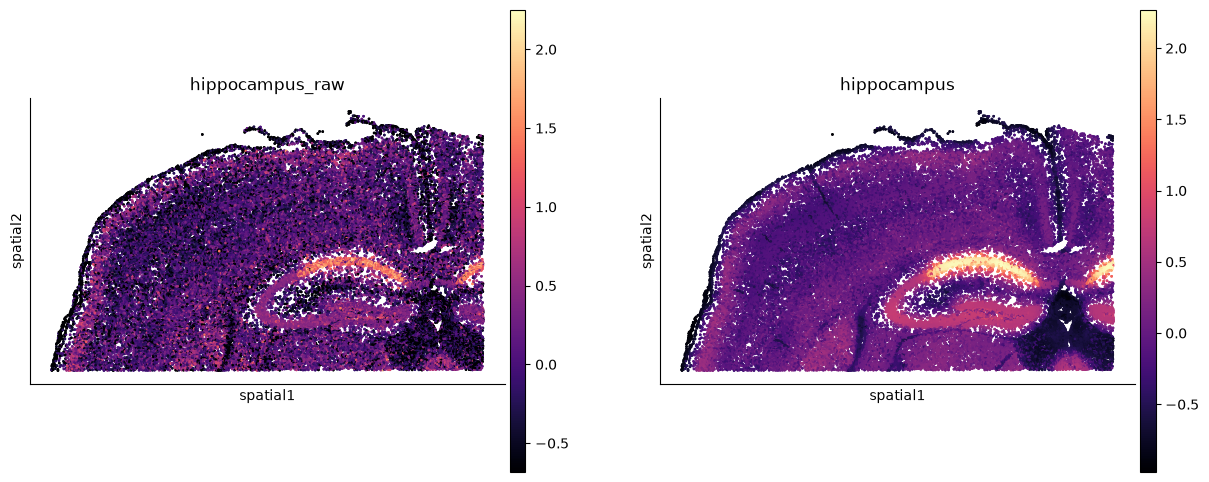

In [8]:
# The same field through squidpy, which knows about tissue images and library ids.
ss.pl.signature(adata, "hippocampus", backend="squidpy", cmap="magma", figsize=(6, 6))

## 3. Rescue a sparse gene

This is what smoothing is *for*. `Chat` is detected in only a few percent of cells: in the raw
score it is a scatter of isolated positive cells with no legible shape. But those cells sit
together in one nucleus, so smoothing lets them reinforce each other and the domain emerges. Same
one call, one gene.

Chat: detected in 3.4% of cells -- raw is mostly zeros


[2026-07-21 16:19:54,260] [INFO    ] Smoothing all 36,419 cells


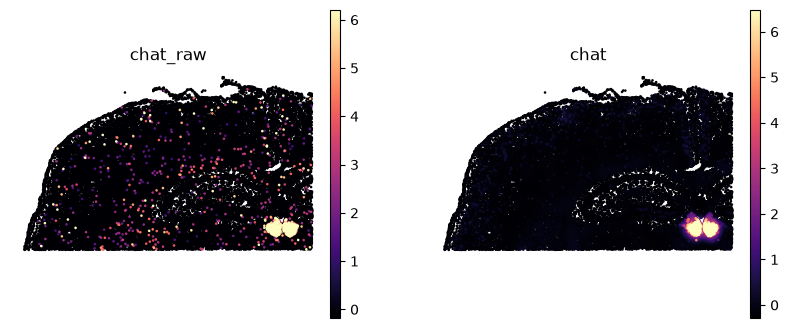

In [9]:
print(f"{SPARSE_GENE}: detected in {detection_rate(SPARSE_GENE):.1%} of cells -- raw is mostly zeros")

ss.smooth(adata, [SPARSE_GENE], "chat", steps="blend")

ss.pl.signature(adata, "chat", raw=True, backend="scanpy", cmap="magma", frameon=False)

Left, the raw gene: a sparse speckle you could not annotate. Right, the smoothed field: the same
handful of positive cells, now pooled with their neighbours, resolve the cholinergic nucleus they
belong to. Nothing about the measurement changed — the raw score is still there in
`obs["chat_raw"]` for any statistics — but the *picture* went from noise to a region you can point
at. (And, once more: the smoothed panel is for **looking**. A test run on it would treat each
cell's borrowed signal as independent evidence and badly overstate the domain.)

## 4. Save your work — compute once, plot forever

The blend above computed a diffusion map: minutes of work. You never have to pay that again.
Everything a smoothing produces is written into the `AnnData` — the smoothed score, its `_raw`
twin, and a provenance record in `uns` — so writing the object to disk and reading it back lets you
re-plot **without recomputing anything**: no `kompot`, no `palantir`, no GP solve.

In [10]:
adata.write_h5ad("smoothed.h5ad")

reloaded = ad.read_h5ad("smoothed.h5ad")
print("stored results:", ss.list_results(reloaded))

stored results: ['chat', 'hippocampus']


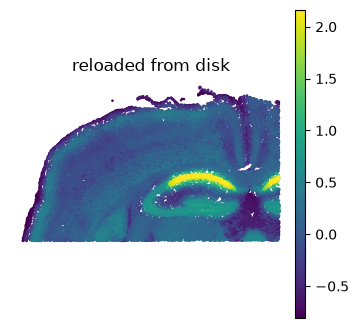

drawing the saved result took 0.30 seconds


In [11]:
# Nothing is recomputed here -- the smoothed values are read straight from the file.
import time
start = time.time()
ss.pl.signature(reloaded, "hippocampus", raw=False, backend="scanpy", frameon=False,
                title="reloaded from disk")
print(f"drawing the saved result took {time.time() - start:.2f} seconds")

Smoothing took minutes; drawing it back from the file took a fraction of a second, because the
field was never recomputed — `spatial_smooth.plot` reads `obs` and `uns` and hands them to scanpy.
That is the whole point of saving: do the expensive step once.

### One honesty check the package runs for you

For full control you can pass `Step` objects directly instead of a shorthand. When a parameter
choice would make the smoother misbehave, the package says so on `stderr`. Here we deliberately
choose too few neighbours (`k=64`) and watch it object.

In [12]:
# k=64 truncates the Gaussian before it has faded. The package keeps this message on purpose.
ss.smooth(adata, SIGNATURE, "tight", steps=[ss.KnnGaussian(basis="spatial", k=64, sigma_factor=4.0)])

res = ss.provenance(adata, "tight")["steps"][0]["resolved"]
print(f"nominal sigma   : {res['sigma_used']:.1f} um   <- do NOT quote this")
print(f"effective sigma : {res['sigma_effective']:.1f} um   <- what the kernel behaves like; quote this")
print(f"kernel mass kept: {res['kernel_mass_retained']:.0%}")

nominal sigma   : 52.1 um   <- do NOT quote this
effective sigma : 35.7 um   <- what the kernel behaves like; quote this
kernel mass kept: 69%


steps.py:198: TruncationWarning: KnnGaussian(k=64) truncates the kernel: only 69% of the Gaussian mass falls within each point's 64-neighbour radius, so the effective bandwidth is 35.7 (nominal sigma 52.1) and varies with local density. Raise k, or quote the effective bandwidth, not the nominal one.
  W, sigma_used, info = knn_gaussian_operator(


The warning is telling you that only ~69% of the Gaussian's weight fell inside each cell's
64-neighbour radius, so the bandwidth the data actually felt is *narrower* than the nominal
`sigma` — and varies from cell to cell. Nothing is broken; a truncated Gaussian is a fine smoother.
But if you were to write "σ = 52 µm" in a methods section you would be quoting a number the code
never applied. `sigma_effective` is the one to report. Raise `k` (the default, 400, keeps ~96% of
the mass) and the warning goes away. The **[Concepts](https://settylab.github.io/spatial-smooth/concepts.html)**
page derives all of this — retained mass, effective bandwidth, why it is density-adaptive.

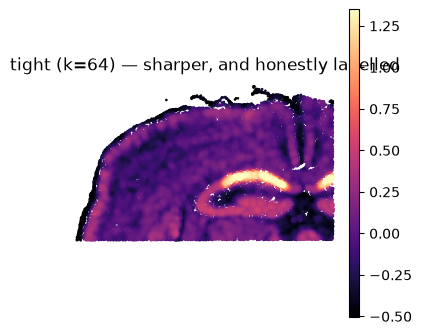

In [13]:
ss.pl.signature(adata, "tight", raw=False, backend="scanpy", cmap="magma", frameon=False,
                title="tight (k=64) — sharper, and honestly labelled")

## 5. Where to go next

That is the happy path: one `blend` call to see a signature, one to rescue a sparse gene, and a
save-and-reload so plotting never recomputes. The package has more, all documented rather than
crammed in here:

* **Other modes** — `steps="spatial"` (space only, the fast default engine), `steps="dm"` (cell
  state only), `steps="dm+spatial"` (sequential composition). One `steps` argument each.
* **Smooth every gene once** — `ss.smooth_all(...)` then `ss.smooth(..., all_genes=True)` derives
  any signature, single gene or blend from the pre-smoothed layers for free (the expensive GP runs
  once).
* **Restrict, condition, and other engines** — smooth a subset of cells, fit the GP on one
  condition and evaluate everywhere, or swap in the KDE / spatial-GP engines.
* **The maths** — composition vs blending, the scoring contract, bandwidth truncation and
  scale-invariance: the **[Concepts](https://settylab.github.io/spatial-smooth/concepts.html)**
  page, with `ss.provenance(adata, name)` giving you exactly what was run on your data.

And once more, because it is the thing that matters: **these smoothed values are for looking at.**
Do your statistics on `adata.obs["hippocampus_raw"]`.